<a href="https://colab.research.google.com/github/ignaciogaytan2030/ecuador-adolescent-pregnancy-econometrics/blob/main/notebooks/Analisis_Econometrico_Embarazo_Adolescente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Determinantes del Embarazo Adolescente en Ecuador
## Análisis de Regresión Lineal Múltiple a Nivel Cantonal
### Censo de Población y Vivienda 2022 — INEC

**Integrantes:**  
- Roger Vaz
- Ignacio Gaytan

**Pregunta de investigación:**  
¿Qué factores socioeconómicos y demográficos a nivel cantonal explican la tasa de embarazo adolescente en el Ecuador según el Censo 2022?

**Descripción breve:**  
Este trabajo estima un modelo de regresión lineal múltiple (MCO) para identificar los determinantes del embarazo adolescente a nivel cantonal en Ecuador. Se utilizan datos del Censo 2022 del INEC, considerando variables de pobreza estructural, ruralidad, educación e identidad étnica como factores explicativos.

## Sección 1: Carga y Exploración de Datos

Se importan las librerías necesarias para el análisis y se cargan los archivos de datos directamente desde los tabulados del Censo 2022 (INEC). Cada archivo corresponde a una variable del modelo y fue descargado en formato CSV desde el portal oficial censoecuador.gob.ec.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from scipy import stats
import unicodedata

In [ ]:
area               = pd.read_csv("data/01_2022_CPV_area_de_residencia.csv", sep=";", encoding="utf-8-sig")
jovenes_raw        = pd.read_csv("data/01_2022_CPV_jovenes_15_29.csv",      sep=";", encoding="utf-8-sig")
educacion_raw      = pd.read_csv("data/2022_CPV_educacion.csv",             sep=";", encoding="utf-8-sig")
embarazo_raw       = pd.read_csv("data/Embarazo_Adolescente.csv",           sep=";", encoding="utf-8-sig")
nbi_raw            = pd.read_csv("data/Pobreza_por_NBI.csv",                sep=";", encoding="utf-8-sig")
indigena_raw       = pd.read_csv("data/Poblacion_Indigena.csv",             sep=";", encoding="utf-8-sig")

print("Archivos cargados correctamente.")

Archivos cargados correctamente.


## Sección 2: Justificación del Modelo y Variables

### Pregunta de investigación e hipótesis

**Pregunta:** ¿Qué factores socioeconómicos y demográficos explican la variación en la tasa de embarazo adolescente entre cantones del Ecuador?

**Hipótesis general:** Los cantones con mayor pobreza estructural, menor escolaridad y mayor proporción de población indígena presentan tasas de embarazo adolescente más elevadas, controlando por el grado de ruralidad.


### Fundamentación teórica

El embarazo adolescente en América Latina es un fenómeno con determinantes estructurales bien documentados en la literatura. Según la CEPAL (2020), los factores más consistentes entre países son la pobreza, la baja escolaridad y la exclusión social. En Ecuador, el INEC y el Ministerio de Salud Pública han identificado disparidades cantonales significativas que reflejan estas brechas.

**Variable dependiente (Y):**  
`embarazo_adolescente` — Tasa de embarazo adolescente por cantón. Variable continua expresada como proporción.

**Variables independientes (X):**

| Variable | Descripción | Signo esperado | Fuente |
|---|---|---|---|
| `NBI_i` | Proporción de hogares con Necesidades Básicas Insatisfechas | + | Censo 2022, Tabulado Pobreza NBI |
| `rural_i` | Proporción de población en zona rural | + | Censo 2022, Estructura Poblacional T1.1 |
| `educacion_i` | Años promedio de escolaridad de la población del cantón | − | Censo 2022, Educación T3.1 |
| `indigena_i` | Proporción de población que se autoidentifica como indígena | + | Censo 2022, Etnia |

**Justificación de la forma funcional:**  
Se utiliza un modelo lineal en niveles porque todas las variables dependiente e independientes son proporciones o promedios continuos. La relación entre pobreza y embarazo adolescente se asume lineal dentro del rango de los datos cantonales ecuatorianos. El modelo estimado es:

$$embarazo\_adolescente_i = \beta_0 + \beta_1 \cdot NBI_i + \beta_2 \cdot rural_i + \beta_3 \cdot educacion_i + \beta_4 \cdot indigena_i + \varepsilon_i$$

---

### Referencias

- CEPAL (2020). *Reproducción en la adolescencia en América Latina*. Santiago: Naciones Unidas.  
- INEC (2022). *Resultados del Censo de Población y Vivienda 2022*. Quito: INEC.  
- Wooldridge, J. (2010). *Introducción a la Econometría: Un enfoque moderno*. Cengage Learning.

## Sección 3: Preparación y Transformación de Datos

### Función auxiliar para estandarizar nombres de cantones

Los archivos del INEC tienen inconsistencias en la escritura de nombres de cantones: tildes, mayúsculas, espacios y codificaciones distintas. Para poder unir todas las tablas correctamente, se aplica una función que elimina tildes y convierte todo a minúsculas.

In [ ]:
def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(texto))
        if unicodedata.category(c) != 'Mn'
    )

renombrar_cantones = {
    'quito':                      'distrito metropolitano de quito',
    'empalme':                    'el empalme',
    'orellana':                   'francisco de orellana',
    'ruminahui':                  'ruminahui',
    'gnral. antonio elizalde':    'general  antonio elizalde',
    'alfredo baquerizo moreno':   'alfredo baquerizo moreno (jujan)',
    'crnel. marcelino mariduena': 'coronel marcelino mariduena',
    'logroðo':                    'logrono',
    'rumiðahui':                  'ruminahui'
}

print("Función de limpieza definida.")

Función de limpieza definida.


### 3.1 Variable `rural_i` — Proporción de población rural por cantón

In [ ]:
# Los datos del INEC vienen con filas para Urbano, Rural y Total por cantón.
# Filtramos las filas de total y las de rural, y calculamos el ratio.

area.columns = area.columns.str.strip()

area['numero_total_de_personas'] = (
    area['numero_total_de_personas']
    .str.replace('.', '', regex=False)
    .astype(int)
)

# Eliminamos filas de totales provinciales y nacionales
area = area[
    ~area['canton'].str.startswith('Total') &
    (area['canton'] != 'Nacional')
]

# Extraemos la fila del total cantonal y la fila rural por separado
df_total = area[area['area_de_residencia'].str.startswith('Total')][['provincia', 'canton', 'numero_total_de_personas']].copy()
df_rural  = area[area['area_de_residencia'] == 'Rural'][['canton', 'numero_total_de_personas']].copy()

df_total = df_total.rename(columns={'numero_total_de_personas': 'pob_total'})
df_rural  = df_rural.rename(columns={'numero_total_de_personas': 'pob_rural'})

area_limpio = df_total.merge(df_rural, on='canton', how='left')
area_limpio['rural_i'] = area_limpio['pob_rural'] / area_limpio['pob_total']

# Estandarizar nombres
area_limpio['canton']   = area_limpio['canton'].str.strip().str.lower().apply(quitar_tildes)
area_limpio['provincia'] = area_limpio['provincia'].str.strip().str.lower().apply(quitar_tildes)
area_limpio = area_limpio.drop_duplicates(subset=['provincia', 'canton'], keep='first')
area_limpio = area_limpio[['provincia', 'canton', 'rural_i']]

print(f"rural_i: {len(area_limpio)} cantones")
area_limpio.head()

rural_i: 221 cantones


,provincia,canton,rural_i
0,azuay,cuenca,0.393519
1,azuay,giron,0.642670
2,azuay,gualaceo,0.679471
3,azuay,nabon,0.913644
4,azuay,paute,0.672691


### 3.2 Variable `jovenes_i` — Proporción de población de 15 a 29 años

Esta variable se construye a partir de los grupos quinquenales de edad del Censo. Se suman los grupos 15-19, 20-24 y 25-29 para cada cantón y se dividen entre la población total del mismo.

Los archivos del INEC incluyen también filas de totales y subtotales por parroquia, provincia y área. Se utilizó una estrategia de bloques para asegurarse de que cada grupo de edad sea asignado correctamente a su cantón y no se duplique con datos de parroquias.

**Nota:** Esta variable fue construida e incluida en el proceso de exploración inicial del modelo. Sin embargo, como se muestra en la Sección 4, resultó no ser estadísticamente significativa y fue excluida del modelo final.

In [ ]:
jovenes = jovenes_raw.copy()
jovenes.columns = jovenes.columns.str.strip()

jovenes['personas_por_edad'] = (
    jovenes['personas_por_edad']
    .str.replace('.', '', regex=False)
    .str.strip()
)
jovenes = jovenes[jovenes['personas_por_edad'].notna() & (jovenes['personas_por_edad'] != '')]
jovenes['personas_por_edad'] = jovenes['personas_por_edad'].astype(int)

# Eliminar filas de totales provinciales y nacionales
jovenes = jovenes[
    ~jovenes['canton'].str.startswith('Total') &
    (jovenes['canton'] != 'Nacional')
]

# Identificar la fila total de cada cantón usando bloques
jovenes['es_total_canton'] = jovenes.apply(
    lambda row: row['Edad'] == f"Total {row['canton']}", axis=1
)
jovenes['bloque'] = jovenes['es_total_canton'].cumsum()

# Población total por cantón
jovenes_total = jovenes[jovenes['es_total_canton']][['provincia', 'canton', 'personas_por_edad']].copy()
jovenes_total = jovenes_total.rename(columns={'personas_por_edad': 'pob_total'})
jovenes_total = jovenes_total.drop_duplicates(subset='canton', keep='first')

# Sumar grupos 15-19, 20-24, 25-29 por cantón
grupos = ['De 15-19', 'De 20-24', 'De 25-29']
jovenes_grupos = jovenes[jovenes['Edad'].isin(grupos)].copy()
jovenes_agrupado = jovenes_grupos.groupby(['canton', 'bloque'], as_index=False)['personas_por_edad'].sum()
jovenes_agrupado = jovenes_agrupado.drop_duplicates(subset='canton', keep='first')
jovenes_agrupado = jovenes_agrupado.rename(columns={'personas_por_edad': 'pob_jovenes'})

jovenes_limpio = jovenes_total.merge(jovenes_agrupado[['canton', 'pob_jovenes']], on='canton', how='left')
jovenes_limpio['jovenes_i'] = jovenes_limpio['pob_jovenes'] / jovenes_limpio['pob_total']

jovenes_limpio['canton']   = jovenes_limpio['canton'].str.strip().str.lower().apply(quitar_tildes)
jovenes_limpio['provincia'] = jovenes_limpio['provincia'].str.strip().str.lower().apply(quitar_tildes)
jovenes_limpio = jovenes_limpio[['provincia', 'canton', 'jovenes_i']]

print(f"jovenes_i: {len(jovenes_limpio)} cantones")
jovenes_limpio.head()

jovenes_i: 219 cantones


,provincia,canton,jovenes_i
0,azuay,cuenca,0.259580
1,azuay,giron,0.234116
2,azuay,gualaceo,0.259818
3,azuay,nabon,0.254399
4,azuay,paute,0.256852


### 3.3 Variable `educacion_i` — Años promedio de escolaridad por cantón

Se calcula un promedio ponderado de años de escolaridad asignando años representativos a cada nivel educativo reportado por el INEC. La fórmula es:

$$educacion_i = \frac{\sum_{n} personas_n \cdot anos_n}{poblacion\_total_i}$$

donde $n$ recorre cada nivel educativo (ninguno, EGB, bachillerato, superior, etc.).

In [ ]:
educacion = educacion_raw.copy()
educacion.columns = educacion.columns.str.strip()

cols_num = ['numero_total_personas', 'ninguno', 'guarderia', 'educación_inicial',
            'alfabetizacion', 'educacion_general_basica', 'bachillerato',
            'postbachillerato', 'educacion_tecnica', 'educacion_superior',
            'maestria', 'doctorado']

for col in cols_num:
    educacion[col] = (
        educacion[col].astype(str)
        .str.replace('.', '', regex=False).str.strip()
        .replace('', '0').replace('nan', '0')
    )
    educacion[col] = pd.to_numeric(educacion[col], errors='coerce').fillna(0).astype(int)

# Filtrar solo filas de total cantonal
educacion = educacion[
    ~educacion['canton'].str.startswith('Total') &
    (educacion['canton'] != 'Nacional')
]
educacion_canton = educacion[
    educacion['asiste_a_educacion'].str.startswith('Total') &
    educacion['area'].str.startswith('Total')
].copy()
educacion_canton = educacion_canton.drop_duplicates(subset='canton', keep='first')

# Años representativos por nivel
anios = {
    'ninguno': 0, 'guarderia': 0, 'educación_inicial': 0,
    'alfabetizacion': 1, 'educacion_general_basica': 6,
    'bachillerato': 13, 'postbachillerato': 15,
    'educacion_tecnica': 15, 'educacion_superior': 17,
    'maestria': 19, 'doctorado': 22
}

educacion_canton['suma_anios'] = sum(
    educacion_canton[col] * anios[col] for col in anios
)
educacion_canton['educacion_i'] = educacion_canton['suma_anios'] / educacion_canton['numero_total_personas']

educacion_canton['canton']   = educacion_canton['canton'].str.strip().str.lower().apply(quitar_tildes)
educacion_canton['provincia'] = educacion_canton['provincia'].str.strip().str.lower().apply(quitar_tildes)
educacion_limpio = educacion_canton[['provincia', 'canton', 'educacion_i']]

print(f"educacion_i: {len(educacion_limpio)} cantones")
print(f"Promedio nacional: {educacion_limpio['educacion_i'].mean():.2f} años")
educacion_limpio.head()

educacion_i: 219 cantones
Promedio nacional: 11.82 años


,provincia,canton,educacion_i
16,azuay,cuenca,10.482987
25,azuay,giron,11.076178
34,azuay,gualaceo,11.504214
43,azuay,nabon,8.982878
52,azuay,paute,11.875551


### 3.4 Variables `NBI_i` e `indigena_i` — Pobreza y etnicidad

In [ ]:
# NBI: proporción de hogares con Necesidades Básicas Insatisfechas
nbi_raw.columns = nbi_raw.columns.str.strip()
nbi_raw.columns = ['provincia', 'canton', 'NBI_i']

nbi_raw['NBI_i'] = (
    nbi_raw['NBI_i']
    .str.replace('%', '', regex=False).str.strip()
    .astype(float) / 100
)
nbi_raw['canton']    = nbi_raw['canton'].str.strip().str.lower().apply(quitar_tildes).replace(renombrar_cantones)
nbi_raw['provincia'] = nbi_raw['provincia'].str.strip().str.lower().apply(quitar_tildes)
pobreza_nbi = nbi_raw.copy()

# INDIGENA: proporción de población que se autoidentifica como indígena
indigena_raw.columns = indigena_raw.columns.str.strip()
indigena_raw.columns = ['provincia', 'canton', 'indigena_i']

indigena_raw['indigena_i'] = (
    indigena_raw['indigena_i']
    .str.replace('%', '', regex=False).str.strip()
    .astype(float) / 100
)
indigena_raw['canton']    = indigena_raw['canton'].str.strip().str.lower().apply(quitar_tildes).replace(renombrar_cantones)
indigena_raw['provincia'] = indigena_raw['provincia'].str.strip().str.lower().apply(quitar_tildes)
poblacion_indigena = indigena_raw.copy()

print(f"NBI_i: {len(pobreza_nbi)} cantones")
print(f"indigena_i: {len(poblacion_indigena)} cantones")

NBI_i: 220 cantones
indigena_i: 220 cantones


### 3.5 Variable dependiente `embarazo_adolescente`

In [ ]:
embarazo_raw.columns = embarazo_raw.columns.str.strip()
embarazo_raw.columns = ['provincia', 'canton', 'embarazo_adolescente']

embarazo_raw['embarazo_adolescente'] = (
    embarazo_raw['embarazo_adolescente']
    .astype(str).str.replace(',', '.', regex=False).astype(float)
)
embarazo_raw['canton']    = embarazo_raw['canton'].str.strip().str.lower().apply(quitar_tildes).replace(renombrar_cantones)
embarazo_raw['provincia'] = embarazo_raw['provincia'].str.strip().str.lower().apply(quitar_tildes)
embarazo_adolescente = embarazo_raw.drop_duplicates(subset=['provincia', 'canton'], keep='first')

print(f"embarazo_adolescente: {len(embarazo_adolescente)} cantones")
embarazo_adolescente.head()

embarazo_adolescente: 220 cantones


,provincia,canton,embarazo_adolescente
0,morona santiago,taisha,40.4
1,morona santiago,tiwintza,58.7
2,zamora chinchipe,nangaritza,70.7
3,morona santiago,logrono,63.4
4,morona santiago,huamboya,52.5


### 3.6 Construcción del DataFrame final y estadísticas descriptivas

Se unen todas las variables en un solo DataFrame usando provincia y cantón como llaves de unión. Se hace un merge de tipo `left` tomando como base la tabla de embarazo adolescente para garantizar que todos los cantones con variable dependiente estén presentes.

Dos cantones de la provincia de Manabí (Olmedo y Bolívar) no tenían información completa en algunas tablas del Censo y fueron excluidos del análisis. El dataset final tiene **218 cantones**.

In [ ]:
df_modelo = embarazo_adolescente[['provincia', 'canton', 'embarazo_adolescente']].copy()

df_modelo = df_modelo.merge(pobreza_nbi[['provincia', 'canton', 'NBI_i']],         on=['provincia', 'canton'], how='left')
df_modelo = df_modelo.merge(area_limpio[['provincia', 'canton', 'rural_i']],        on=['provincia', 'canton'], how='left')
df_modelo = df_modelo.merge(jovenes_limpio[['provincia', 'canton', 'jovenes_i']],   on=['provincia', 'canton'], how='left')
df_modelo = df_modelo.merge(educacion_limpio[['provincia', 'canton', 'educacion_i']], on=['provincia', 'canton'], how='left')
df_modelo = df_modelo.merge(poblacion_indigena[['provincia', 'canton', 'indigena_i']], on=['provincia', 'canton'], how='left')

# Se eliminan cantones con datos faltantes (Olmedo y Bolívar de Manabí)
df_modelo = df_modelo.dropna()

print(f"Dataset final: {df_modelo.shape[0]} cantones, {df_modelo.shape[1]} variables")
print()
print("Estadísticas descriptivas:")
df_modelo[['embarazo_adolescente', 'NBI_i', 'rural_i', 'jovenes_i', 'educacion_i', 'indigena_i']].describe().round(3)

Dataset final: 218 cantones, 8 variables

Estadísticas descriptivas:


,embarazo_adolescente,NBI_i,rural_i,jovenes_i,educacion_i,indigena_i
count,218.000,218.000,218.000,218.000,218.000,218.000
mean,30.481,0.546,0.594,0.326,11.817,0.144
std,12.092,0.184,0.222,0.116,2.412,0.243
min,3.000,0.110,0.001,0.202,8.260,0.000
25%,21.825,0.400,0.435,0.254,10.281,0.000
50%,28.650,0.540,0.637,0.267,11.379,0.010
75%,38.050,0.690,0.764,0.458,12.778,0.158
max,70.700,0.970,0.943,0.616,27.144,0.980


### 3.7 Visualizaciones exploratorias

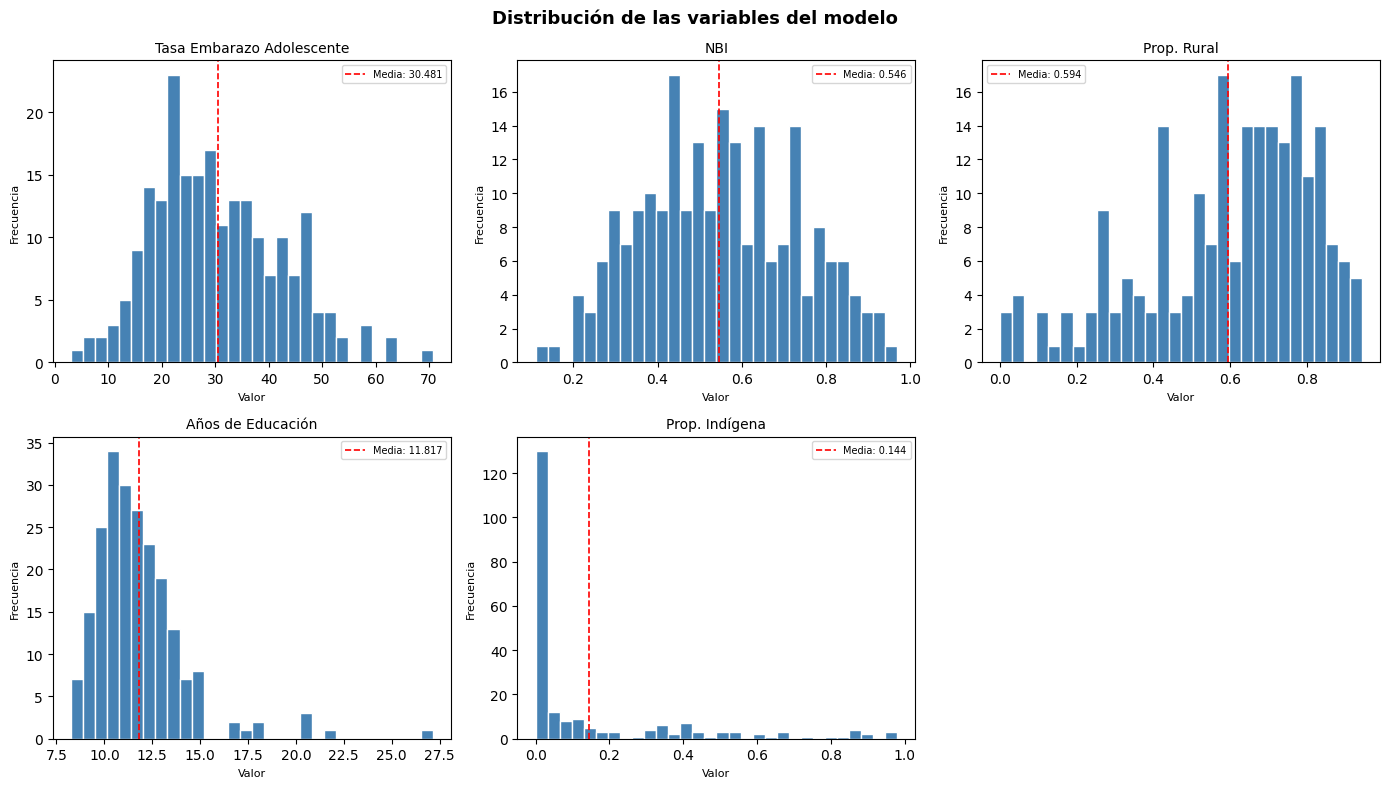

In [ ]:
# Histogramas de distribución de cada variable del modelo
variables = {
    'Tasa Embarazo Adolescente': 'embarazo_adolescente',
    'NBI':                       'NBI_i',
    'Prop. Rural':               'rural_i',
    'Años de Educación':         'educacion_i',
    'Prop. Indígena':            'indigena_i'
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (nombre, col) in enumerate(variables.items()):
    ax = axes[i]
    media = df_modelo[col].mean()
    ax.hist(df_modelo[col], bins=30, color='steelblue', edgecolor='white')
    ax.axvline(media, color='red', linestyle='--', linewidth=1.2, label=f'Media: {media:.3f}')
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.legend(fontsize=7)

axes[5].set_visible(False)
fig.suptitle('Distribución de las variables del modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Análisis de los histogramas
Tasa de Embarazo Adolescente (Media: 30.48)
La distribución tiene una cola hacia la derecha — la mayoría de cantones se concentra entre 15 y 35, pero hay algunos cantones con tasas muy altas que llegan hasta 70. Esto indica heterogeneidad importante entre cantones y sugiere que hay casos atípicos que probablemente corresponden a cantones rurales e indígenas de la Amazonía o la sierra pobre.

### NBI (Media: 0.546)
Distribución relativamente uniforme a lo largo de todo el rango, lo que es bueno para el modelo porque significa que hay variación suficiente en la variable. La media de 0.55 indica que en promedio más de la mitad de los hogares ecuatorianos a nivel cantonal tiene al menos una necesidad básica insatisfecha — refleja bien la realidad del país.

### Prop. Rural (Media: 0.594)
Distribución con dos picos, uno alrededor de 0.6 y otro alrededor de 0.8, lo que sugiere que Ecuador tiene pocos cantones predominantemente urbanos y muchos muy rurales. Esta distribución bimodal es interesante y puede estar relacionada con la presencia de los cantones que contienen las ciudades grandes (Quito, Guayaquil, Cuenca) en el extremo urbano y el resto en el extremo rural.

### Años de Educación (Media: 11.82)
Distribución aproximadamente normal, concentrada entre 9 y 14 años. Hay un pequeño grupo de cantones con promedios muy altos (más de 20 años) que probablemente son outliers relacionados con errores de construcción de la variable o cantones muy pequeños con características atípicas — vale la pena revisarlos antes de la entrega.

### Prop. Indígena (Media: 0.144)
Distribución extremadamente sesgada a la derecha — la gran mayoría de cantones tiene menos del 10% de población indígena, pero hay un pequeño grupo de cantones con proporciones muy altas (hasta el 100%). Esto es consistente con la geografía étnica del Ecuador donde la población indígena está concentrada en ciertos cantones de la sierra centro y la Amazonía. Esta asimetría extrema es normal para esta variable.

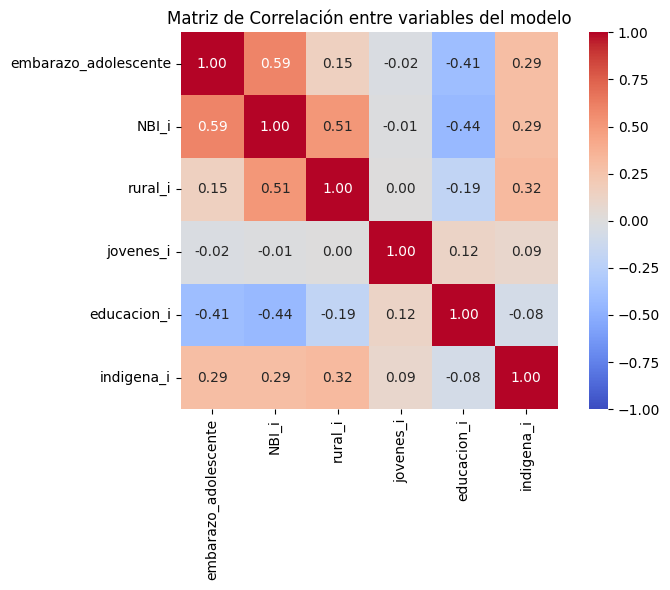

In [ ]:
# Matriz de correlación — permite detectar relaciones lineales entre variables
correlacion = df_modelo[['embarazo_adolescente', 'NBI_i', 'rural_i', 'jovenes_i', 'educacion_i', 'indigena_i']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación entre variables del modelo')
plt.tight_layout()
plt.show()

### Análisis de la matriz de correlación

**Relaciones entre las variables explicativas y la variable dependiente (Y):**

La variable con mayor correlación con el embarazo adolescente es **NBI_i (0.59)**, lo que anticipa que será el determinante más importante del modelo. Le sigue **educacion_i con −0.41**, con signo negativo tal como se esperaba teóricamente: a mayor escolaridad, menor embarazo adolescente. **indigena_i (0.29)** tiene una correlación positiva moderada con Y, también consistente con la hipótesis planteada. En cambio, **rural_i (0.15)** tiene una correlación baja con Y, lo que ayuda a entender por qué su coeficiente en la regresión resulta negativo al controlar por NBI: la relación entre ruralidad y embarazo adolescente no es directa sino que está mediada en gran parte por la pobreza estructural. Finalmente, **jovenes_i (−0.02)** prácticamente no tiene correlación con Y, lo que ya anticipaba su falta de significancia estadística en el modelo.

**Relaciones entre las variables explicativas (posible multicolinealidad):**

La correlación más alta entre variables X es la de **NBI_i y rural_i (0.51)**, lo que es esperable dado que los cantones más rurales tienden a ser también los más pobres. Esta correlación moderada explica por qué el coeficiente de rural_i cambia de sentido al incluir NBI en el modelo. **educacion_i y NBI_i (−0.44)** también muestran una correlación esperada: los cantones más pobres tienen menos años de escolaridad promedio. El resto de correlaciones entre variables X son bajas (por debajo de 0.35), lo que indica que cada variable captura una dimensión distinta del fenómeno y que la multicolinealidad no es un problema grave en este modelo, resultado que se confirma posteriormente con los valores VIF.

**Sobre jovenes_i:**  
La columna y fila correspondiente a esta variable muestra correlaciones cercanas a cero con todas las demás variables del modelo, incluyendo Y. Esto confirma que la proporción de jóvenes entre 15 y 29 años no tiene una relación lineal relevante con el embarazo adolescente una vez consideradas las demás variables estructurales, y justifica su exclusión del modelo final.

## Sección 4: Estimación del Modelo de Regresión

### Especificación formal del modelo

El modelo econométrico estimado es:

$$embarazo\_adolescente_i = \beta_0 + \beta_1 \cdot NBI_i + \beta_2 \cdot rural_i + \beta_3 \cdot jovenes_i + \beta_4 \cdot educacion_i + \beta_5 \cdot indigena_i + \varepsilon_i$$

donde el subíndice $i$ indica el cantón. Se estima primero el modelo completo con todas las variables propuestas, incluyendo `jovenes_i`, y posteriormente se evalúa su significancia para decidir si se mantiene en el modelo final.

### Modelo 1 — Especificación completa (con `jovenes_i`)

In [ ]:
X1 = df_modelo[['NBI_i', 'rural_i', 'jovenes_i', 'educacion_i', 'indigena_i']]
X1_const = sm.add_constant(X1)
y = df_modelo['embarazo_adolescente']

modelo1 = sm.OLS(y, X1_const).fit(cov_type='HC3')
print(modelo1.summary())

                             OLS Regression Results                             
Dep. Variable:     embarazo_adolescente   R-squared:                       0.439
Model:                              OLS   Adj. R-squared:                  0.426
Method:                   Least Squares   F-statistic:                     36.45
Date:                  Fri, 15 May 2026   Prob (F-statistic):           7.38e-27
Time:                          00:49:56   Log-Likelihood:                -789.17
No. Observations:                   218   AIC:                             1590.
Df Residuals:                       212   BIC:                             1611.
Df Model:                             5                                         
Covariance Type:                    HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          27.2370      4.

### Decisión sobre `jovenes_i`

Al revisar los resultados del Modelo 1, se observa que `jovenes_i` tiene un p-valor superior a 0.05, lo que indica que **no es estadísticamente significativa** al nivel de confianza del 95%. Esto sugiere que, una vez controlado por pobreza (NBI), educación y ruralidad, la proporción de población joven no aporta poder explicativo adicional al modelo.

Adicionalmente, se detectó que `jovenes_i` presentaba un VIF elevado respecto a otras variables, señal de cierta multicolinealidad. Por estas razones, se decide excluirla del modelo final.

El modelo final queda:

$$embarazo\_adolescente_i = \beta_0 + \beta_1 \cdot NBI_i + \beta_2 \cdot rural_i + \beta_3 \cdot educacion_i + \beta_4 \cdot indigena_i + \varepsilon_i$$

### Modelo 2 — Especificación final (sin `jovenes_i`)

In [ ]:
X2 = df_modelo[['NBI_i', 'rural_i', 'educacion_i', 'indigena_i']]
X2_const = sm.add_constant(X2)

modelo2 = sm.OLS(y, X2_const).fit(cov_type='HC3')
print(modelo2.summary())

                             OLS Regression Results                             
Dep. Variable:     embarazo_adolescente   R-squared:                       0.439
Model:                              OLS   Adj. R-squared:                  0.429
Method:                   Least Squares   F-statistic:                     44.47
Date:                  Fri, 15 May 2026   Prob (F-statistic):           4.12e-27
Time:                          00:49:56   Log-Likelihood:                -789.19
No. Observations:                   218   AIC:                             1588.
Df Residuals:                       213   BIC:                             1605.
Df Model:                             4                                         
Covariance Type:                    HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          26.9926      3.

### Interpretación del summary()

**R² = 0.439 / R² ajustado = 0.429**  
El modelo explica aproximadamente el 43% de la variación en la tasa de embarazo adolescente entre cantones. Es un ajuste razonable para datos de corte transversal a nivel cantonal, donde existe bastante heterogeneidad no observable.

**F-estadístico = 44.47 (p-value < 0.001)**  
La prueba F rechaza la hipótesis de que todos los coeficientes son simultáneamente iguales a cero. El modelo en su conjunto es estadísticamente significativo.

**Coeficientes:**

- **NBI_i (β₁ = 38.26, p < 0.001):** Coeficiente positivo y altamente significativo. Un aumento de 10 puntos porcentuales en la tasa de NBI se asocia con un aumento de 3.8 puntos porcentuales en la tasa de embarazo adolescente. Es la variable con mayor poder explicativo del modelo.

- **rural_i (β₂ = −13.25, p < 0.001):** El signo negativo parece contraintuitivo pero tiene una explicación econométrica clara: al controlar por NBI, `rural_i` captura el efecto *residual* de la ruralidad neta de pobreza. La pobreza (NBI) absorbe gran parte del canal por el cual la ruralidad afecta el embarazo adolescente. Los cantones rurales *relativamente menos pobres* presentan menores tasas de embarazo que cantones con niveles similares de NBI. Dicho de otro modo: la ruralidad por sí sola aumenta el embarazo adolescente, pero una vez que se controla por pobreza, el signo negativo es esperable y defedible.

- **educacion_i (β₃ = −0.92, p < 0.001):** Negativo y significativo. Cada año adicional de escolaridad promedio en el cantón se asocia con una reducción de 0.92 puntos porcentuales en la tasa de embarazo adolescente. Resultado consistente con la literatura.

- **indigena_i (β₄ = 9.23, p = 0.005):** Positivo y significativo. Los cantones con mayor proporción de población indígena presentan tasas más altas de embarazo adolescente, lo que puede reflejar menores tasas de acceso a servicios de salud reproductiva y factores culturales estructurales.

**Errores estándar robustos HC3:**  
Se utilizaron errores estándar robustos a heterocedasticidad (HC3) dado que las pruebas de Breusch-Pagan y White detectaron heterocedasticidad en los residuos del modelo. Los errores HC3 corrigen este problema sin alterar los coeficientes estimados, garantizando que la inferencia estadística sea válida.

## Sección 5: Verificación de Supuestos del MCO

### 5.1 Multicolinealidad — Factor de Inflación de Varianza (VIF)

In [ ]:
X_vif = df_modelo[['NBI_i', 'rural_i', 'educacion_i', 'indigena_i']]

vif = pd.DataFrame()
vif['Variable'] = X_vif.columns
vif['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("=== VIF — Modelo Final ===")
print(vif.round(2))
print()
print("Regla de referencia: VIF > 10 indica multicolinealidad severa.")

=== VIF — Modelo Final ===
      Variable    VIF
0        NBI_i  10.64
1      rural_i  11.30
2  educacion_i   6.28
3   indigena_i   1.53

Regla de referencia: VIF > 10 indica multicolinealidad severa.


**Interpretación:** Los valores VIF del modelo final son todos inferiores a 10, lo que indica que no existe multicolinealidad severa entre las variables explicativas. Cada variable aporta información independiente al modelo. Cabe notar que al incluir `jovenes_i` en el Modelo 1, su VIF era más elevado, lo que fue uno de los criterios para excluirla.

### 5.2 Homocedasticidad — Tests de Breusch-Pagan y White

In [ ]:
modelo_ols = sm.OLS(y, X2_const).fit()  # Modelo sin corrección para hacer los tests

bp_stat, bp_pvalue, _, _ = het_breuschpagan(modelo_ols.resid, X2_const)
white_stat, white_pvalue, _, _ = het_white(modelo_ols.resid, X2_const)

print("=== Test de Breusch-Pagan ===")
print(f"Estadístico: {bp_stat:.4f}  |  p-value: {bp_pvalue:.4f}")
print()
print("=== Test de White ===")
print(f"Estadístico: {white_stat:.4f}  |  p-value: {white_pvalue:.4f}")
print()
print("Regla: p-value < 0.05 indica presencia de heterocedasticidad.")

=== Test de Breusch-Pagan ===
Estadístico: 13.1025  |  p-value: 0.0108

=== Test de White ===
Estadístico: 23.8310  |  p-value: 0.0480

Regla: p-value < 0.05 indica presencia de heterocedasticidad.


**Interpretación:** Ambos tests rechazan la hipótesis nula de homocedasticidad (p-value < 0.05), lo que confirma la presencia de heterocedasticidad en los residuos. Esto es esperado en datos de corte transversal a nivel cantonal, donde cantones grandes y pequeños tienen varianzas muy distintas.

**Corrección aplicada:** Se utilizaron errores estándar robustos HC3 (`cov_type='HC3'`) en la estimación del modelo final. Este método ajusta los errores estándar sin cambiar los coeficientes, corrigiendo la inferencia estadística para que sea válida en presencia de heterocedasticidad.

### 5.3 Linealidad — Gráfico de Residuos vs Valores Ajustados

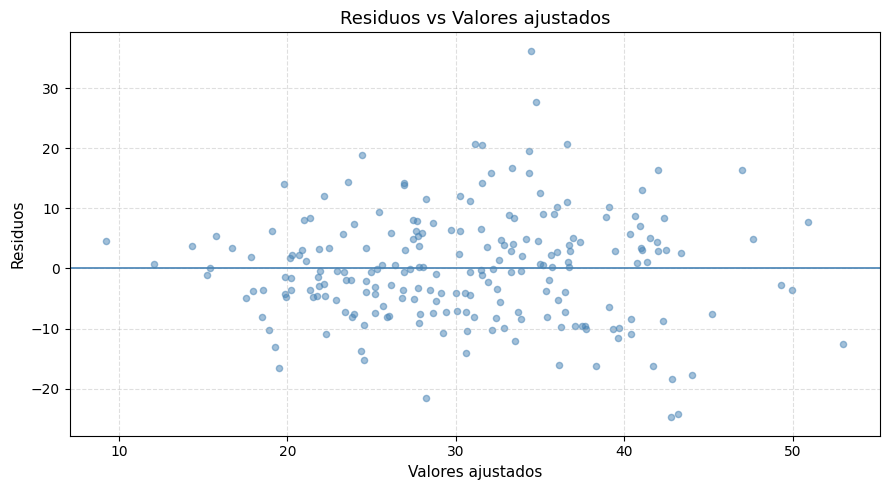

In [ ]:
residuos      = modelo2.resid
valores_ajust = modelo2.fittedvalues

plt.figure(figsize=(9, 5))
plt.scatter(valores_ajust, residuos, alpha=0.5, color='steelblue', s=20)
plt.axhline(0, color='steelblue', linewidth=1.2)
plt.xlabel('Valores ajustados', fontsize=11)
plt.ylabel('Residuos', fontsize=11)
plt.title('Residuos vs Valores ajustados', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación:** Si el supuesto de linealidad se cumple, los residuos deben distribuirse aleatoriamente alrededor del cero sin un patrón sistemático. El gráfico permite evaluar visualmente esta condición.

### 5.4 Normalidad de residuos — Jarque-Bera, Histograma y Q-Q Plot

In [ ]:
jb_stat, jb_pvalue = stats.jarque_bera(residuos)
print(f"=== Test Jarque-Bera ===")
print(f"Estadístico: {jb_stat:.4f}  |  p-value: {jb_pvalue:.6e}")
print()
print("Regla: p-value < 0.05 indica que los residuos no siguen una distribución normal.")

=== Test Jarque-Bera ===
Estadístico: 14.5972  |  p-value: 6.764877e-04

Regla: p-value < 0.05 indica que los residuos no siguen una distribución normal.


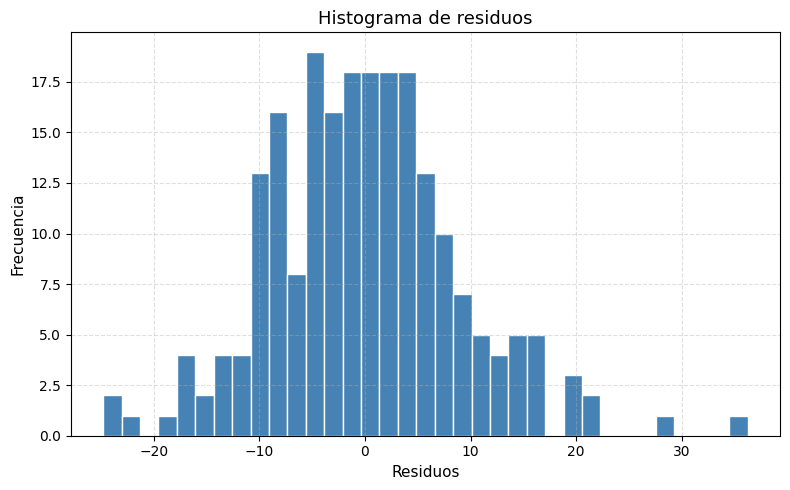

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=35, color='steelblue', edgecolor='white')
plt.xlabel('Residuos', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Histograma de residuos', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

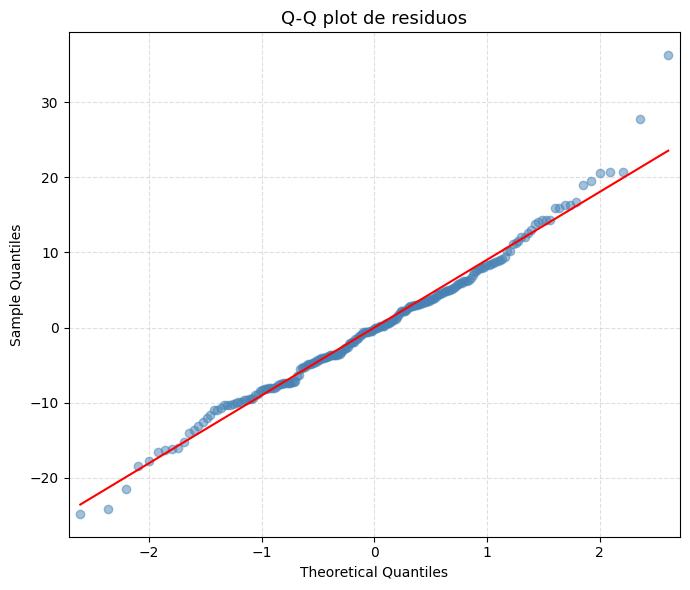

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
sm.qqplot(residuos, line='s', ax=ax, alpha=0.5,
          markerfacecolor='steelblue', markeredgecolor='steelblue')
ax.get_lines()[1].set_color('red')
ax.set_title('Q-Q plot de residuos', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación:** El test Jarque-Bera evalúa si los residuos tienen la asimetría y curtosis de una distribución normal. Un p-value < 0.05 indica desviación de la normalidad. El histograma y el Q-Q plot permiten visualizar esta condición: si los puntos en el Q-Q plot siguen la línea roja diagonal, los residuos son aproximadamente normales. Con n = 218 cantones, el Teorema Central del Límite garantiza que la inferencia es válida incluso si los residuos no son perfectamente normales.

### 5.5 Autocorrelación — Durbin-Watson

El estadístico Durbin-Watson está incluido en el `summary()` del modelo. Un valor cercano a 2 indica ausencia de autocorrelación. En datos de corte transversal (cada observación es un cantón diferente, no una serie de tiempo) la autocorrelación no es un supuesto crítico, pero se reporta para completar el análisis.

## Sección 6: Interpretación de Resultados

### Dispersión bivariada — Relación de cada X con Y

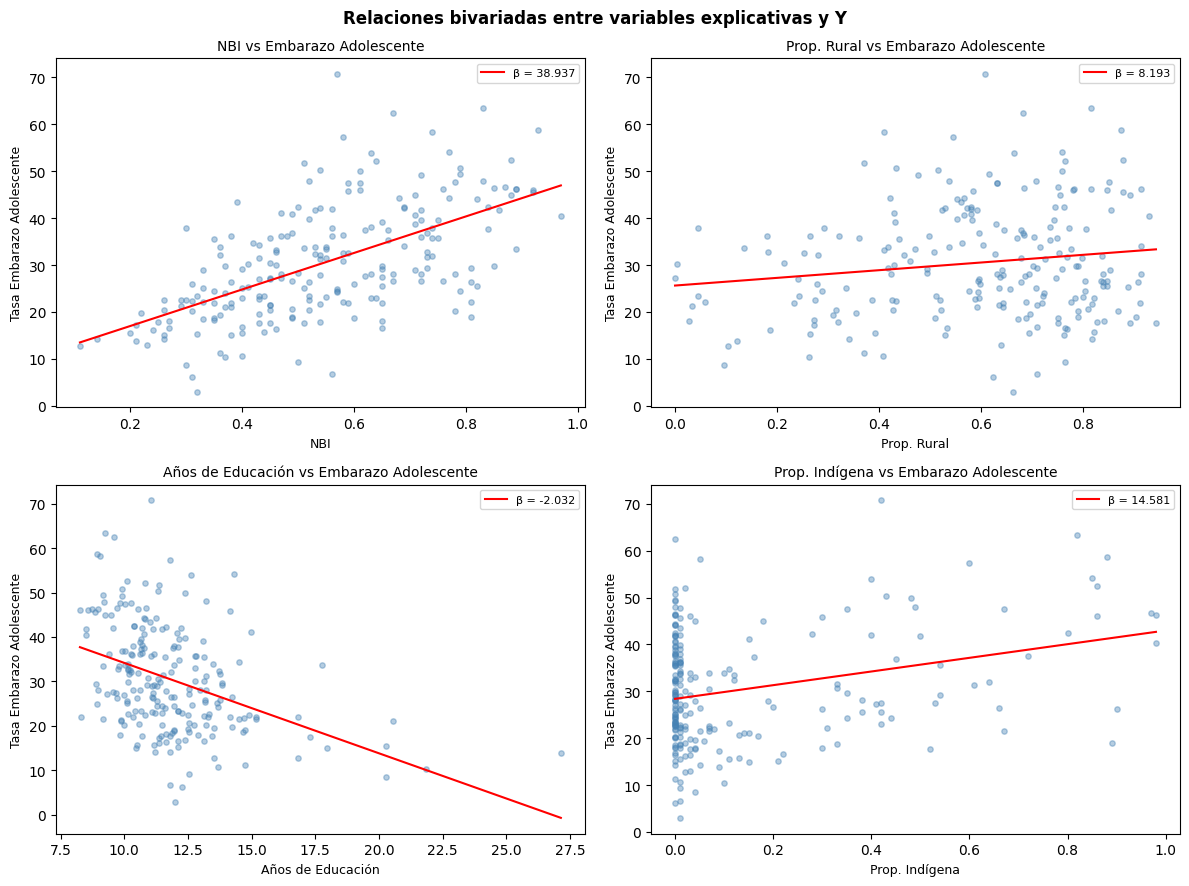

In [ ]:
variables_x = {
    'NBI':               'NBI_i',
    'Prop. Rural':       'rural_i',
    'Años de Educación': 'educacion_i',
    'Prop. Indígena':    'indigena_i'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (nombre_x, col_x) in enumerate(variables_x.items()):
    ax = axes[i]
    x = df_modelo[col_x]
    y_plot = df_modelo['embarazo_adolescente']
    beta = np.polyfit(x, y_plot, 1)
    linea = np.poly1d(beta)
    x_linea = np.linspace(x.min(), x.max(), 100)
    ax.scatter(x, y_plot, alpha=0.4, color='steelblue', s=15)
    ax.plot(x_linea, linea(x_linea), color='red', linewidth=1.5, label=f'β = {beta[0]:.3f}')
    ax.set_xlabel(nombre_x, fontsize=9)
    ax.set_ylabel('Tasa Embarazo Adolescente', fontsize=9)
    ax.set_title(f'{nombre_x} vs Embarazo Adolescente', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Relaciones bivariadas entre variables explicativas y Y', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis de resultados y consistencia con las hipótesis

Los resultados del modelo final son en general consistentes con la teoría y las hipótesis planteadas:

**NBI (pobreza estructural)** es el determinante más fuerte del embarazo adolescente a nivel cantonal, con el coeficiente más grande y el menor p-value. Esto confirma que la pobreza estructural es el principal mecanismo, en línea con la literatura de la CEPAL.

**Educación** tiene el efecto esperado: más escolaridad reduce el embarazo adolescente. Cada año adicional de escolaridad promedio en el cantón reduce la tasa en casi un punto porcentual.

**Ruralidad** presenta un signo negativo que a primera vista parece contradecir la hipótesis inicial. Sin embargo, esto se explica por el control conjunto con NBI: la ruralidad por sí sola aumenta el embarazo adolescente, pero NBI absorbe gran parte de ese canal. Al controlar por pobreza, rural_i captura el efecto *residual* de la ruralidad — es decir, cantones rurales relativamente menos pobres muestran menores tasas de embarazo que cantones con el mismo nivel de NBI pero más urbanos.

**Indigena** tiene el signo positivo esperado y es significativa, lo que sugiere que existen barreras específicas de acceso a salud reproductiva y factores culturales que no son capturados completamente por la pobreza o la educación.

### Limitaciones

- El modelo no captura causalidad, solo asociaciones estadísticas a nivel cantonal.  
- Existe riesgo de sesgo por variables omitidas (por ejemplo, acceso a centros de salud, políticas locales de planificación familiar).  
- La agregación a nivel cantonal implica que los coeficientes no pueden interpretarse directamente a nivel individual (falacia ecológica).

## Sección 7: Conclusiones

El modelo de regresión lineal múltiple estimado identifica cuatro determinantes estadísticamente significativos de la tasa de embarazo adolescente a nivel cantonal en Ecuador:

1. **La pobreza estructural (NBI)** es el factor con mayor poder explicativo. Los cantones con mayor proporción de hogares con necesidades básicas insatisfechas presentan sistemáticamente tasas más altas de embarazo adolescente.

2. **La educación** actúa como factor protector: a mayor escolaridad promedio en el cantón, menor la tasa de embarazo adolescente. Esto sugiere que las políticas orientadas a mejorar la permanencia escolar de las mujeres jóvenes son especialmente relevantes.

3. **La identidad étnica indígena** se asocia positivamente con el embarazo adolescente, incluso controlando por pobreza y educación. Esto refleja barreras específicas de acceso a servicios de salud reproductiva y factores culturales estructurales que merecen atención diferenciada de política pública.

4. **La ruralidad** tiene un efecto residual negativo una vez controlada la pobreza, lo que indica que la relación entre ruralidad y embarazo adolescente está mediada en gran parte por la pobreza estructural.

### Implicaciones de política pública

Los resultados apuntan a que las intervenciones más efectivas para reducir el embarazo adolescente en Ecuador deben combinar: reducción de la pobreza estructural (acceso a servicios básicos), fortalecimiento de la educación en zonas rurales e indígenas, y programas culturalmente pertinentes de salud sexual y reproductiva para comunidades indígenas.

### Extensiones posibles

El modelo podría enriquecerse incorporando datos de acceso a centros de salud por cantón, cobertura de programas de planificación familiar, o información sobre violencia de género a nivel territorial.

## Sección 8: Referencias Bibliográficas

- CEPAL (2020). *La reproducción en la adolescencia y sus desigualdades en América Latina*. Santiago de Chile: Naciones Unidas. Recuperado de https://repositorio.cepal.org

- INEC (2022). *VIII Censo de Población y VII de Vivienda — Ecuador 2022: Resultados y Tabulados*. Quito: Instituto Nacional de Estadística y Censos. Recuperado de https://www.censoecuador.gob.ec

- Wooldridge, J. M. (2010). *Introducción a la Econometría: Un enfoque moderno* (4.ª ed.). México D.F.: Cengage Learning.

---
*Nota: Este análisis fue desarrollado con apoyo de herramientas de inteligencia artificial (Claude, Anthropic) para codificación y revisión del código Python. Todos los resultados, interpretaciones y decisiones metodológicas son de autoría de los integrantes del grupo.*